In [ ]:
import torch
import pandas
import matplotlib.pyplot as plt


torch.set_default_device('cuda')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

(null): No such file or directory
(null): No such file or directory
(null): No such file or directory
(null): No such file or directory


In [4]:
training_data = torch.from_numpy(pandas.read_csv('data/train.csv').to_numpy()).T

In [5]:
test_data = training_data[:,30000:]
training_data = training_data[:,:30000]

In [6]:
# initialise trainign data
X_train = training_data[1:,:] / 255
Y_train = training_data[0,:]
Y_one_hot = torch.eye(10)[Y_train]

X_train = X_train.to(device)
Y_train = Y_train.to(device)
Y_one_hot = Y_one_hot.to(device)

In [7]:
# initialise test data
X_test = test_data[1:,:] / 255
Y_test = test_data[0,:]
Y_test_one_hot = torch.eye(10)[Y_test]

X_test = X_test.to(device)
Y_test = Y_test.to(device)
Y_test_one_hot = Y_test_one_hot.to(device)

In [ ]:
class initialisation:
  def __self__(self, neurons, weights, device):
    self.neurons = neurons
    self.weights = weights
    self.device = device

  def He_initialisation(neurons, weights, device):
    return torch.randn(neurons, weights, device=device) * torch.sqrt(2 / torch.tensor(weights))

  def zeros_initialisation(neurons, device):
    return torch.zeros(neurons, 1, device=device)

def initialise_parameters():
  W1 = initialisation.He_initialisation(128,784,device)
  b1 = initialisation.zeros_initialisation(128,device)

  W2 = initialisation.He_initialisation(64,128,device)
  b2 = initialisation.zeros_initialisation(64,device)

  W3 = initialisation.He_initialisation(32,64,device)
  b3 = initialisation.zeros_initialisation(32,device)

  W4 = initialisation.He_initialisation(10,32,device)
  b4 = initialisation.zeros_initialisation(10,device)

  return W1, b1, W2, b2, W3, b3, W4, b4

initialise_parameters()

(tensor([[-1.0965e-01,  6.4255e-03, -2.6317e-02,  ..., -7.2447e-03,
           9.4729e-07,  1.3906e-02],
         [-9.8081e-03, -1.0561e-01,  1.3726e-02,  ..., -3.2144e-02,
          -4.3506e-02,  3.4237e-02],
         [-4.8499e-02, -7.2831e-02,  1.0948e-01,  ..., -5.0898e-03,
           3.3249e-02,  7.5078e-03],
         ...,
         [-5.9106e-02, -2.3673e-02,  6.1980e-02,  ..., -4.7779e-03,
           5.2942e-02,  9.8708e-02],
         [ 3.9771e-02,  4.7436e-02, -6.1285e-02,  ..., -1.3807e-02,
          -2.7993e-02,  1.2024e-02],
         [ 7.8668e-02, -7.8119e-04, -5.1611e-02,  ..., -7.2193e-03,
           1.9357e-01, -3.2900e-02]], device='cuda:0'),
 tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
       

In [9]:
# Activation functions
class ReLU:
  def __init__(self):
    self.Z = None

  def __call__(self, Z):
    self.Z = Z
    return torch.clamp(Z,min=0)

  def deriv(self,Z):
    self.Z = Z
    return (self.Z>0).float()
  
class Softmax:
  def __init__(self):
    self.Z = None
  
  def __call__(self, Z):
    self.Z = Z
    max_Z = torch.max(Z, dim=0, keepdim=True).values
    exp_Z = torch.exp(Z - max_Z)
    sum_exp_Z = torch.sum(exp_Z, dim=0, keepdim=True)
    return exp_Z / sum_exp_Z

relu = ReLU()
softmax = Softmax()

In [10]:
def get_accuracy(output, Y):
  accuracy = torch.sum(output == Y).item() / (len(Y))
  return accuracy

In [ ]:
def forward_prop(X, Y, W1, b1, W2, b2, W3, b3, W4, b4):
  A0 = X
  
  Z1 = (W1 @ A0) + b1
  A1 = relu(Z1)
  
  Z2 = (W2 @ A1) + b2
  A2 = relu(Z2)

  Z3 = (W3 @ A2) + b3
  A3 = relu(Z3)

  Z4 = (W4 @ A3) + b4
  A4 = softmax(Z4)

  output = torch.argmax(A4, axis=0)
  accuracy = get_accuracy(output, Y)
  
  return A0, Z1, A1, Z2, A2, Z3, A3, Z4, A4, accuracy

In [12]:
def back_prop(X, Y, batch_size, Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3, Z4, A4, W4, b4):
  loss = -(1 / batch_size) * torch.sum(Y.T * torch.log(A4 + 1e-8))

  dZ4 = A4 - Y.T
  dW4 = (1 / batch_size) * dZ4 @ A3.T
  db4 = (1 / batch_size) * torch.sum(dZ4, dim=1, keepdim=True)

  dZ3 = (W4.T @ dZ4) * relu.deriv(Z3)
  dW3 = (1 / batch_size) * dZ3 @ A2.T
  db3 = (1 / batch_size) * torch.sum(dZ3, dim=1, keepdim=True)

  dZ2 = (W3.T @ dZ3) * relu.deriv(Z2)
  dW2 = (1 / batch_size) * dZ2 @ A1.T
  db2 = (1 / batch_size) * torch.sum(dZ2, dim=1, keepdim=True)

  dZ1 = (W2.T @ dZ2) * relu.deriv(Z1)
  dW1 = (1 / batch_size) * dZ1 @ X.T
  db1 = (1 / batch_size) * torch.sum(dZ1, dim=1, keepdim=True)

  return dW4, db4, dW3, db3, dW2, db2, dW1, db1, loss

In [13]:
def update_parameters(learning_rate, W1, b1, dW1, db1, W2, b2, dW2, db2, W3, b3, dW3, db3, W4, b4, dW4, db4):

  W1 -= dW1 * learning_rate
  b1 -= db1 * learning_rate
  W2 -= dW2 * learning_rate
  b2 -= db2 * learning_rate
  W3 -= dW3 * learning_rate
  b3 -= db3 * learning_rate
  W4 -= dW4 * learning_rate
  b4 -= db4 * learning_rate

  return W1, b1, W2, b2, W3, b3, W4, b4

In [19]:
def gradient_descent(learning_rate, num_samples, batch_size, epochs, X_train, Y_train, Y_one_hot, W1, b1, W2, b2, W3, b3, W4, b4):
  accuracy_list = []
  loss_list = []

  for epoch in range(epochs):

    perm = torch.randperm(num_samples, device=device)
    X_train_shuffled = X_train[:,perm]
    Y_train_shuffled = Y_train[perm]
    Y_one_hot_shuffled = Y_one_hot[perm]
    
    for i in range(0, num_samples, batch_size):
      X_batch = X_train_shuffled[:,i:i + batch_size]
      Y_batch = Y_one_hot_shuffled[i:i + batch_size,:]
      Y_true = Y_train_shuffled[i:i + batch_size]

      A0, Z1, A1, Z2, A2, Z3, A3, Z4, A4, accuracy = forward_prop(X_batch, Y_true, W1, b1, W2, b2, W3, b3, W4, b4)
      dW4, db4, dW3, db3, dW2, db2, dW1, db1, loss = back_prop(X_batch, Y_batch, batch_size, Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3, Z4, A4, W4, b4)
      W1, b1, W2, b2, W3, b3, W4, b4 = update_parameters(learning_rate, W1, b1, dW1, db1, W2, b2, dW2, db2, W3, b3, dW3, db3, W4, b4, dW4, db4)
      dW1, db1, dW2, db2, dW3, db3, dW4, db4 = None, None, None, None, None, None, None, None
      loss_list.append(loss.item())
      accuracy_list.append(accuracy)
      
    print(f"Epoch {epoch + 1}/{epochs} complete")

  return W1, b1, W2, b2, W3, b3, W4, b4, accuracy_list, loss_list

In [28]:
learning_rate = 1e-1
batch_size = 100
epochs = 10
num_samples = X_train.shape[1]

W1, b1, W2, b2, W3, b3, W4, b4 = initialise_parameters()
W1_trained, b1_trained, W2_trained, b2_trained, W3_trained, b3_trained, W4_trained, b4_trained, accuracy_list, loss_list = gradient_descent(learning_rate, num_samples, batch_size, epochs, X_train, Y_train, Y_one_hot, W1, b1, W2, b2, W3, b3, W4, b4)

Epoch 1/10 complete
Epoch 2/10 complete
Epoch 3/10 complete
Epoch 4/10 complete
Epoch 5/10 complete
Epoch 6/10 complete
Epoch 7/10 complete
Epoch 8/10 complete
Epoch 9/10 complete
Epoch 10/10 complete


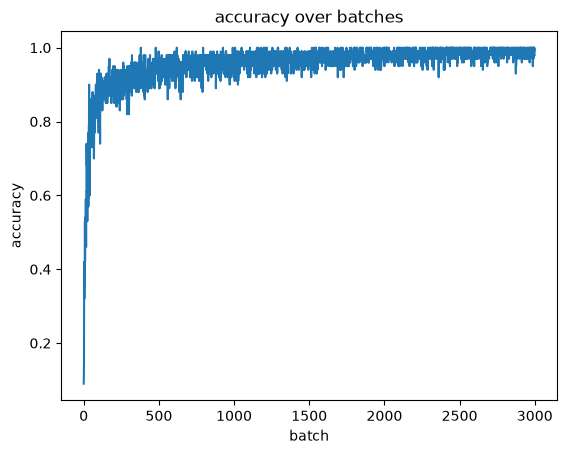

In [29]:
plt.xlabel('batch')
plt.ylabel('accuracy')
plt.title('accuracy over batches')
plt.plot(accuracy_list)

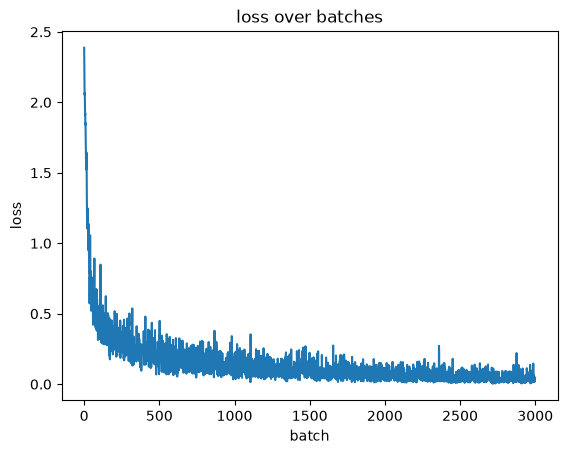

In [30]:
plt.xlabel('batch')
plt.ylabel('loss')
plt.title('loss over batches')
plt.plot(loss_list)

In [18]:
A0, Z1, A1, Z2, A2, Z3, A3, Z4, A4, accuracy = forward_prop(X_test, Y_test, W1_trained, b1_trained, W2_trained, b2_trained, W3_trained, b3_trained, W4_trained, b4_trained)
print(accuracy)

0.9673333333333334
